In [3]:
##Import Library
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("car_fuel_efficiency_2026.csv")

In [5]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [22]:
len(df)

10000

In [6]:
cols = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

In [7]:
df = df[cols]

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  10000 non-null  int64  
 1   horsepower           9123 non-null   float64
 2   vehicle_weight       10000 non-null  int64  
 3   model_year           10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


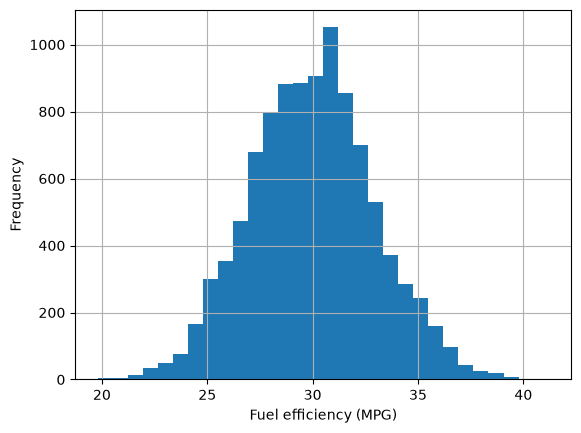

In [10]:
##Look at the `fuel_efficiency_mpg` variable. Does it have a long tail?

import matplotlib.pyplot as plt

df['fuel_efficiency_mpg'].hist(bins=30)

plt.xlabel('Fuel efficiency (MPG)')
plt.ylabel('Frequency')
plt.show()

In [14]:
df['fuel_efficiency_mpg'].describe()

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

In [12]:
### Question 1
### There's one column with missing values. What is it?

In [15]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [16]:
### Question 2
### What's the median (50% percentile) for variable `'horsepower'`?

In [17]:
df['horsepower'].median()

np.float64(254.0)

In [18]:
### Prepare and split the dataset

In [19]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [20]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [24]:
### Question 3
##* We need to deal with missing values for the column from Q1.
##* We have two options: fill it with 0 or with the mean of this variable.
##* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
##* For computing the mean, use the training only!
##* Use the validation dataset to evaluate the models and compare the RMSE of each option.
##* Round the RMSE scores to 3 decimal digits using `round(score, 3)`. This
##  keeps the imputation difference visible in this release.
##* Which option gives better RMSE?

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

In [27]:
features = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]

target = 'fuel_efficiency_mpg'

In [29]:
X_train = df_train[features]
y_train = df_train[target]

X_val = df_val[features]
y_val = df_val[target]

In [30]:
X_train_0 = X_train.copy()
X_val_0 = X_val.copy()

X_train_0['horsepower'] = X_train_0['horsepower'].fillna(0)
X_val_0['horsepower'] = X_val_0['horsepower'].fillna(0)

In [32]:
model = LinearRegression()
model.fit(X_train_0, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-0. ,-0. ,-0. , 0.1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['engine_displacement','horsepower','vehicle_weight','model_year']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-153.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [33]:
y_pred = model.predict(X_val_0)

In [34]:
rmse_0 = root_mean_squared_error(y_val, y_pred)

round(rmse_0, 3)

2.205

In [35]:
mean_hp = X_train['horsepower'].mean()

mean_hp

np.float64(254.46338337605272)

In [36]:
X_train_mean = X_train.copy()
X_val_mean = X_val.copy()

X_train_mean['horsepower'] = X_train_mean['horsepower'].fillna(mean_hp)
X_val_mean['horsepower'] = X_val_mean['horsepower'].fillna(mean_hp)


In [37]:
model = LinearRegression()
model.fit(X_train_mean, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-0. ,-0.01,-0. , 0.1 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['engine_displacement','horsepower','vehicle_weight','model_year']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-153.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [38]:
y_pred = model.predict(X_val_mean)

In [39]:
rmse_mean = root_mean_squared_error(y_val, y_pred)

round(rmse_mean, 3)

2.202

In [40]:
round(rmse_0, 3), round(rmse_mean, 3)

(2.205, 2.202)

In [41]:
### Question 4

###* Now let's train a regularized linear regression.
###* For this question, fill the NAs with 0. 
###* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
###* Use RMSE to evaluate the model on the validation dataset.
###* Round the RMSE scores to 4 decimal digits. This keeps the small but real
###  regularization differences visible instead of turning several choices into a tie.
###* Which `r` gives the best RMSE?

###If multiple options give the same best RMSE, select the smallest `r`.

In [42]:
from sklearn.linear_model import Ridge

X_train = df_train[features].copy()
X_val = df_val[features].copy()

X_train['horsepower'] = X_train['horsepower'].fillna(0)
X_val['horsepower'] = X_val['horsepower'].fillna(0)

In [43]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    model = Ridge(alpha=r)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    rmse = root_mean_squared_error(y_val, y_pred)

    print(r, round(rmse, 4))

0 2.2053
0.01 2.2053
0.1 2.2053
1 2.2053
5 2.2053
10 2.2053
100 2.2053


In [44]:
### Question 5 

###* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
###* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
###* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
###* Fill the missing values with 0 and train a model without regularization.
###* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
###* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
###* Round the result to 3 decimal digits (`round(std, 3)`)

###What's the value of std?

In [65]:
scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:

    # Split the data
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[n_train + n_val:]

    # Create X/y
    X_train = df_train[
        ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
    ].copy()

    X_val = df_val[
        ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
    ].copy()

    y_train = df_train['fuel_efficiency_mpg']
    y_val = df_val['fuel_efficiency_mpg']

    # Fill missing horsepower with 0
    X_train['horsepower'] = X_train['horsepower'].fillna(0)
    X_val['horsepower'] = X_val['horsepower'].fillna(0)

    # Linear regression, no regularization
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Validation prediction
    y_pred = model.predict(X_val)

    # RMSE
    rmse = root_mean_squared_error(y_val, y_pred)

    scores.append(rmse)

    print(seed, rmse)

print("scores:", scores)
print("std:", np.std(scores))
print("rounded:", round(np.std(scores), 3))


0 2.2392041430507534
1 2.202112821083734
2 2.163419778753079
3 2.204358876852931
4 2.2018800943317713
5 2.245785150908142
6 2.2697212079516524
7 2.190794599935421
8 2.2166112016944193
9 2.20703659282341
scores: [2.2392041430507534, 2.202112821083734, 2.163419778753079, 2.204358876852931, 2.2018800943317713, 2.245785150908142, 2.2697212079516524, 2.190794599935421, 2.2166112016944193, 2.20703659282341]
std: 0.028781274078199606
rounded: 0.029


In [66]:
np.std(scores)

np.float64(0.028781274078199606)

In [51]:
### Question 6

#* Split the dataset like previously, use seed 9.
#* Combine train and validation datasets.
#* Fill the missing values with 0 and train a model with `r=0.001`. 
#* What's the RMSE on the test dataset?

In [102]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[n_train + n_val:]


In [103]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [104]:
df_train_full = pd.concat([df_train, df_val])

In [105]:
features = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]

target = 'fuel_efficiency_mpg'

X_train_full = df_train_full[features].copy()
y_train_full = df_train_full[target]

X_test = df_test[features].copy()
y_test = df_test[target]

In [106]:
X_train_full['horsepower'] = X_train_full['horsepower'].fillna(0)
X_test['horsepower'] = X_test['horsepower'].fillna(0)

In [107]:
def train_linear_regression_reg(X, y, r=0):
    X = np.column_stack([np.ones(len(X)), X])

    XTX = X.T @ X

    reg = r * np.eye(XTX.shape[0])
    reg[0, 0] = 0

    XTX_reg = XTX + reg

    XTX_inv = np.linalg.inv(XTX_reg)

    w = XTX_inv @ X.T @ y

    return w


In [108]:
w = train_linear_regression_reg(
    X_train_full,
    y_train_full,
    r=0.001
)

In [109]:
X_test_matrix = np.column_stack([
    np.ones(len(X_test)),
    X_test
])

In [110]:
y_pred = X_test_matrix @ w

In [111]:
rmse = root_mean_squared_error(y_test, y_pred)

print(rmse)
print(round(rmse, 3))

2.2763828107567488
2.276


In [113]:
print("Dataset shape:", df_q6.shape)
print("Train:", len(df_train))
print("Validation:", len(df_val))
print("Test:", len(df_test))
print("Train full:", len(df_train_full))
print("Missing horsepower:", df_q6['horsepower'].isna().sum())
print("RMSE:", rmse)


Dataset shape: (10000, 5)
Train: 6000
Validation: 2000
Test: 2000
Train full: 8000
Missing horsepower: 877
RMSE: 2.2763828107587534
